In [1]:
import sys
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.simulation import sample_initial_state, rollout_trajectory
from source.stochastic_processes import make_price_function
from source.utils import read_csv
from source.system import SystemParams
from source.policy import NeuralPolicy

from source.plotting import *

import pandas as pd


## Training curve

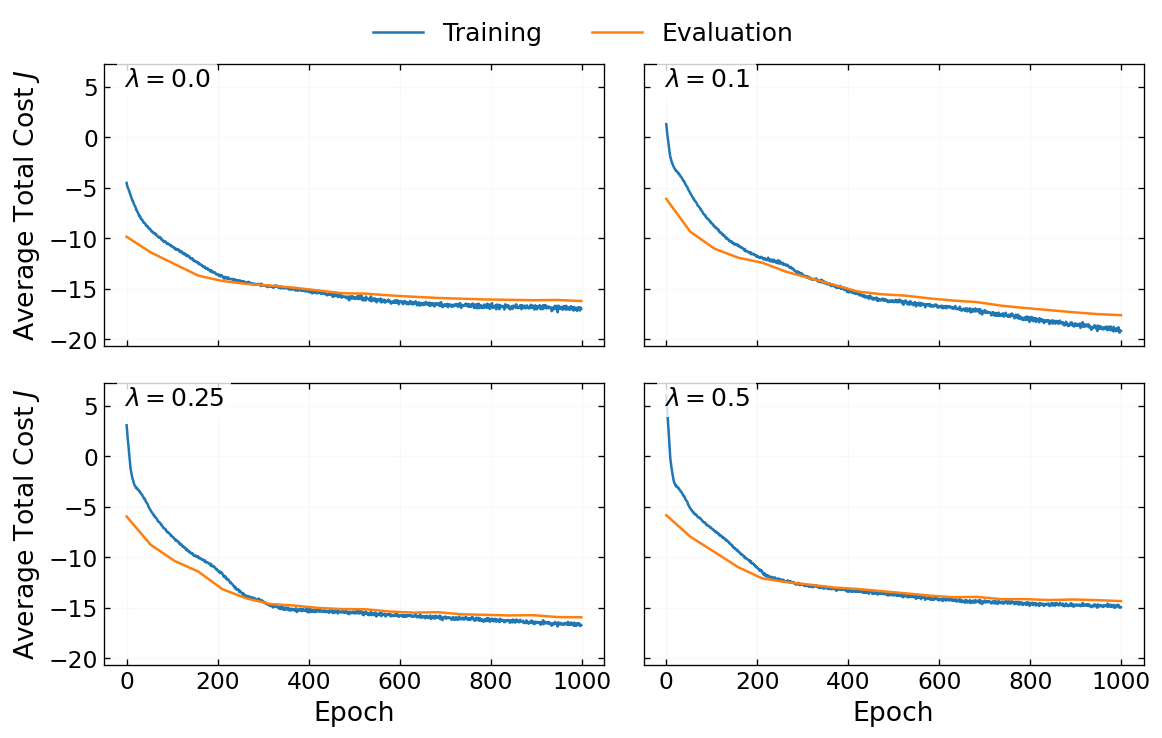

In [2]:
device = torch.device("cpu")
epochs = 1000

checkpoint = torch.load(
    "../checkpoints/lambda_experiments/all_results.pt",
    map_location=device,
    weights_only=False
)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (lambda_cost, res) in zip(axes, checkpoint.items()):
    J_train = res["J_train_hist"]
    J_eval = res["J_eval_hist"]
    epochs = range(len(J_train))
    eval_epochs = np.linspace(0, len(J_train)-1, len(J_eval))

    l1, = ax.plot(epochs, J_train, label="Training")
    l2, = ax.plot(eval_epochs, J_eval, label="Evaluation")

    ax.text(
        0.04, 0.92,
        rf"$\lambda = {lambda_cost}$",
        transform=ax.transAxes,
        fontsize=15,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

for i in range(len(axes)):
  if i % 2 == 0:
    axes[i].set_ylabel("Average Total Cost $J$")
  if i >= 2:
    axes[i].set_xlabel("Epoch")

legend = fig.legend(handles=[l1, l2], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)
plt.tight_layout()
fig.savefig("../figures/objective_vs_epochs.pdf", bbox_inches="tight", bbox_extra_artists=[legend] )
plt.show()

## Untrained policy

In [3]:
params = SystemParams()

T = 24
energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:T]
future_price = energy_prices[T:]

S0 = sample_initial_state(
    batch_size=1000,
    params=params,
    device=device,
    seed=123
)

In [ ]:
policy_untrained = NeuralPolicy().to(device)
policy_untrained.eval()

next_price_function = make_price_function(price_history, future_price, params)

with torch.no_grad():
    history = rollout_trajectory(policy_untrained, S0.clone(), params, next_price_function)

S = history["state"].cpu().numpy()
endog = history["endog"].cpu().numpy()
u = history["control"].cpu().numpy()
c = history["cost"].cpu().numpy()

J_eval_untrained = c.sum(axis=0).mean()

avg_cost = c.mean()
std_cost = c.std()

avg_E = S[:,:,2].mean()
avg_eta = u[:,:,0].mean()
avg_delta = u[:,:,1].mean()
avg_gamma = u[:,:,2].mean()

avg_q  = endog[:,:,0].mean()
avg_ec = endog[:,:,1].mean()
avg_ed = endog[:,:,2].mean()
avg_Ub = endog[:,:,3].mean()
avg_Us = endog[:,:,4].mean()

untrained = pd.Series({
    "lambda": None,
    "J_eval": J_eval_untrained,
    "avg_cost": avg_cost,
    "std_cost": std_cost,
    "avg_E": avg_E,
    "avg_eta": avg_eta,
    "avg_delta": avg_delta,
    "avg_gamma": avg_gamma,
    "avg_q": avg_q,
    "avg_ec": avg_ec,
    "avg_ed": avg_ed,
    "avg_Ub": avg_Ub,
    "avg_Us": avg_Us
})

untrained_res = {
    "time": history["time"].cpu(),
    "state": history["state"].cpu(),
    "control": history["control"].cpu(),
    "cost": history["cost"].cpu(),
    "endog": history["endog"].cpu()
}

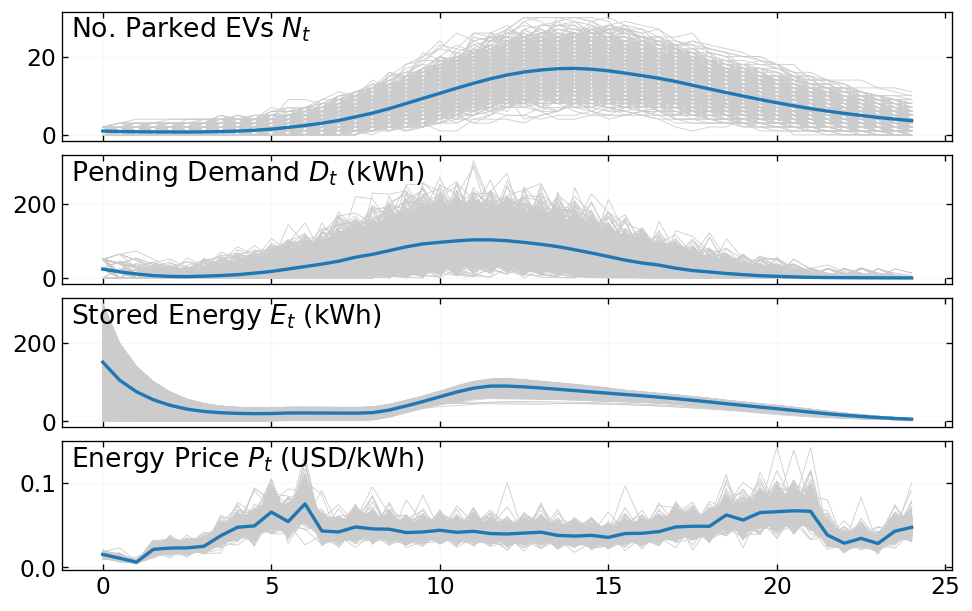

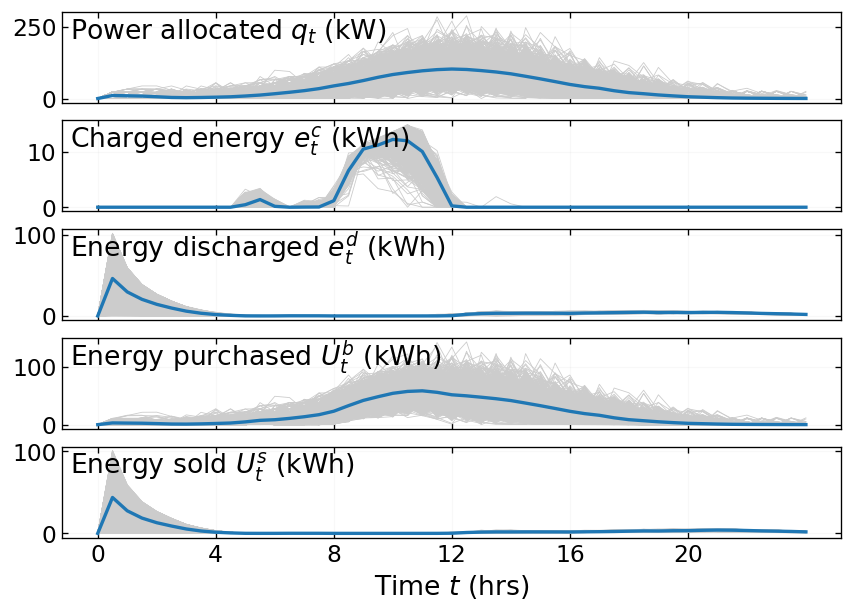

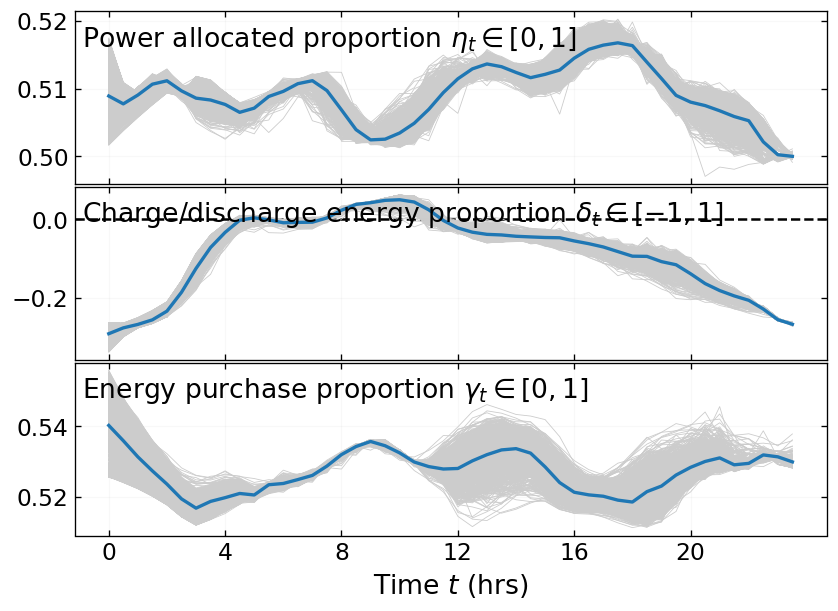

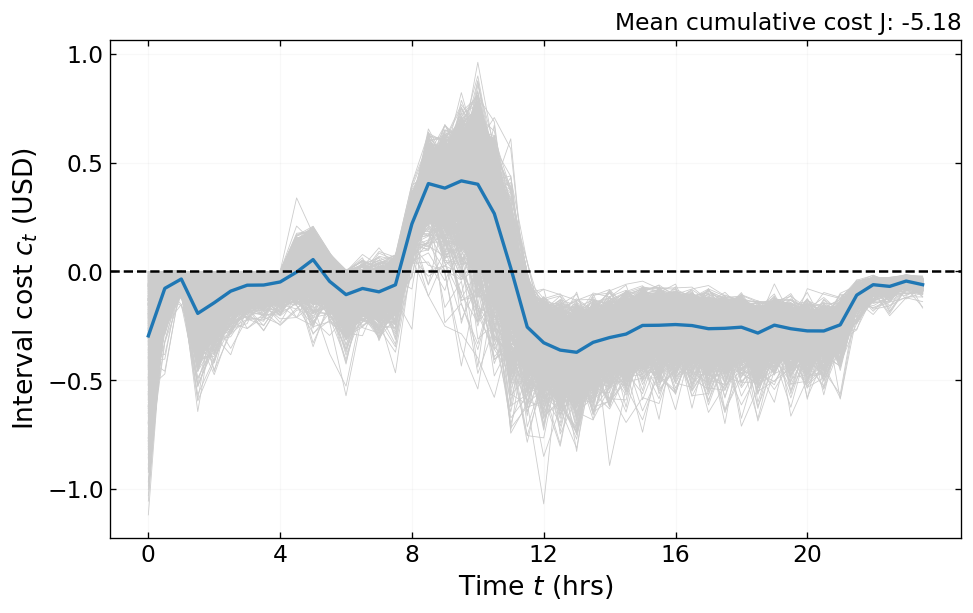

In [ ]:
plot_state_trajectories(
    history["time"], history["state"], f"../figures/states_untrained_nn.pdf"
)
plot_endogenous_trajectories(
    history["time"], history["endog"], f'../figures/endog_untrained_nn.pdf'
    )
plot_control_trajectories(
    history["time"], history["control"], f"../figures/controls_untrained_nn.pdf"
    )
plot_cost_trajectories(
    history["time"], history["cost"], history["J_episode"], f"../figures/costs_untrained_nn.pdf")

## Lamba experiment

In [ ]:
traj_results = {}

for lambda_cost, res in checkpoint.items():

    policy = NeuralPolicy().to(device)
    policy.load_state_dict(res["best_state"])
    policy.eval()

    next_price_function = make_price_function(price_history, future_price, params)

    with torch.no_grad():
        history = rollout_trajectory(policy, S0.clone(), params, next_price_function)

    traj_results[lambda_cost] = history

In [ ]:
import pandas as pd

rows = []

for lambda_cost, res in traj_results.items():

    S = res["state"].numpy()
    endog = res["endog"].numpy()
    u = res["control"].numpy()
    c = res["cost"].numpy()

    N = S[:,:,0]
    D = S[:,:,1]
    E = S[:,:,2]
    P = S[:,:,3]

    q  = endog[:,:,0]
    ec = endog[:,:,1]
    ed = endog[:,:,2]
    Ub = endog[:,:,3]
    Us = endog[:,:,4]

    eta = u[:,:,0]
    delta = u[:,:,1]
    gamma = u[:,:,2]

    J_eval = checkpoint[lambda_cost]["best_J"]

    avg_cost = c.mean()
    std_cost = c.std()

    avg_E = E.mean()
    avg_eta = eta.mean()
    avg_delta = delta.mean()
    avg_gamma = gamma.mean()

    avg_q = q.mean()
    avg_ec = ec.mean()
    avg_ed = ed.mean()
    avg_Ub = Ub.mean()
    avg_Us = Us.mean()

    rows.append({
        "lambda": lambda_cost,
        "J_eval": J_eval,
        "avg_cost": avg_cost,
        "std_cost": std_cost,
        "avg_E": avg_E,
        "avg_eta": avg_eta,
        "avg_delta": avg_delta,
        "avg_gamma": avg_gamma,
        "avg_q": avg_q,
        "avg_ec": avg_ec,
        "avg_ed": avg_ed,
        "avg_Ub": avg_Ub,
        "avg_Us": avg_Us
    })

df = pd.DataFrame(rows).sort_values("lambda")

In [8]:
full = pd.concat((untrained.to_frame().T, df))
full = full.round(4)
full

,lambda,J_eval,avg_cost,std_cost,avg_E,avg_eta,avg_delta,avg_gamma,avg_q,avg_ec,avg_ed,avg_Ub,avg_Us
0,NaN,-5.1809,-0.1079,0.2293,47.0704,0.5091,-0.0860,0.5273,34.7248,1.4596,4.4333,18.1074,3.7187
0,0.00,-17.3436,-0.3986,2.4426,78.3076,0.4520,-0.3112,0.0485,26.0135,3.9163,6.9930,14.7874,4.8574
1,0.10,-19.3648,-0.4843,2.3685,178.6264,0.3852,0.0414,0.0594,15.9040,7.1594,10.2361,11.2689,6.3936
2,0.25,-16.8683,-0.4267,1.5980,184.9102,0.3379,-0.0215,0.1140,15.3614,4.0060,7.0826,8.1393,3.5352
3,0.50,-15.0228,-0.4102,1.3482,190.2021,0.3346,-0.0373,0.1313,16.0607,3.3804,6.4568,7.9336,2.9796


In [9]:
full[
    ["lambda", "J_eval", "avg_cost", "std_cost","avg_eta", "avg_delta","avg_gamma"]
].to_latex(index=False, float_format="%.4f")

'\\begin{tabular}{rrrrrrr}\n\\toprule\nlambda & J_eval & avg_cost & std_cost & avg_eta & avg_delta & avg_gamma \\\\\n\\midrule\nNaN & -5.1809 & -0.1079 & 0.2293 & 0.5091 & -0.0860 & 0.5273 \\\\\n0.0000 & -17.3436 & -0.3986 & 2.4426 & 0.4520 & -0.3112 & 0.0485 \\\\\n0.1000 & -19.3648 & -0.4843 & 2.3685 & 0.3852 & 0.0414 & 0.0594 \\\\\n0.2500 & -16.8683 & -0.4267 & 1.5980 & 0.3379 & -0.0215 & 0.1140 \\\\\n0.5000 & -15.0228 & -0.4102 & 1.3482 & 0.3346 & -0.0373 & 0.1313 \\\\\n\\bottomrule\n\\end{tabular}\n'

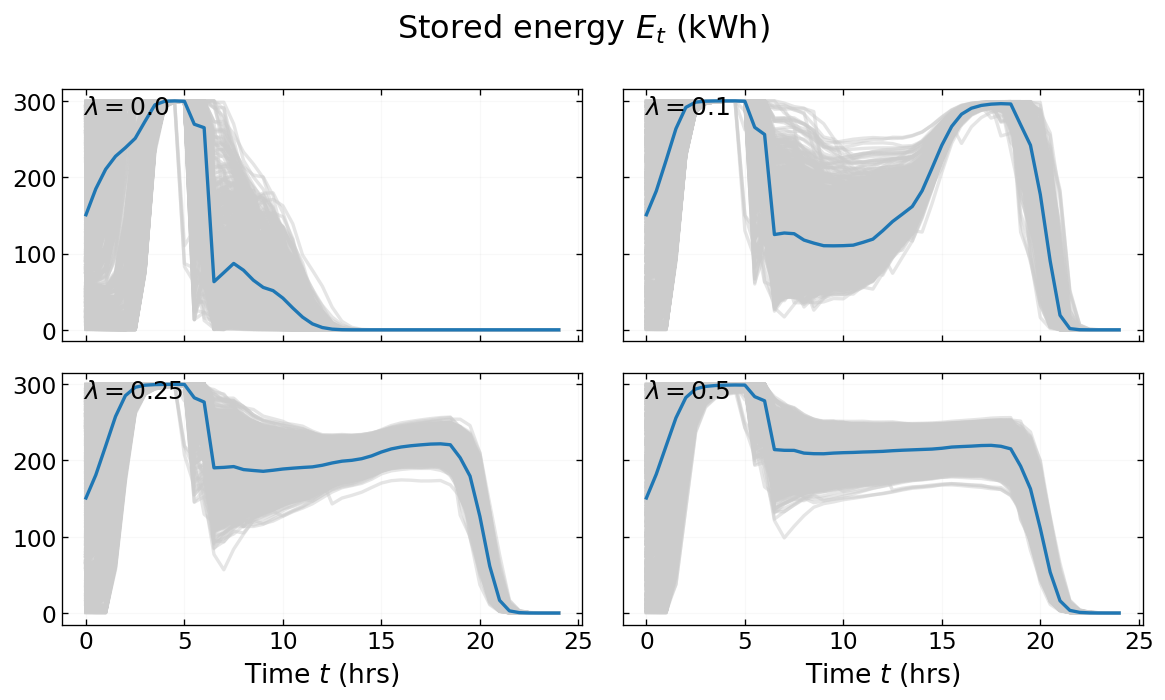

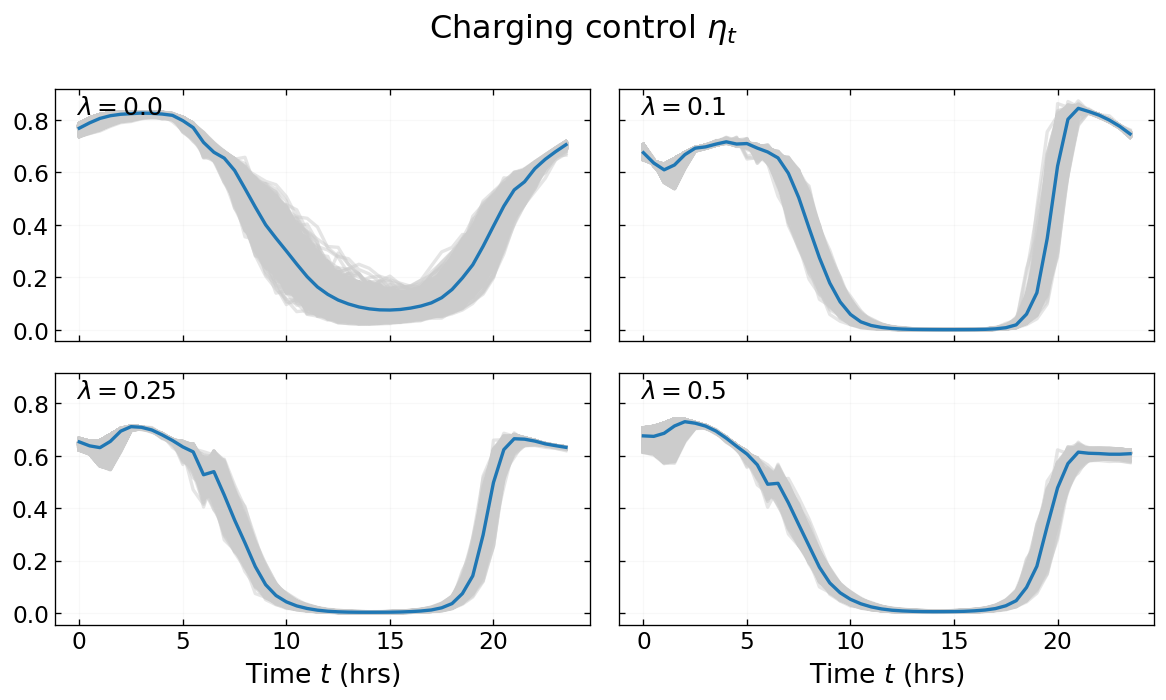

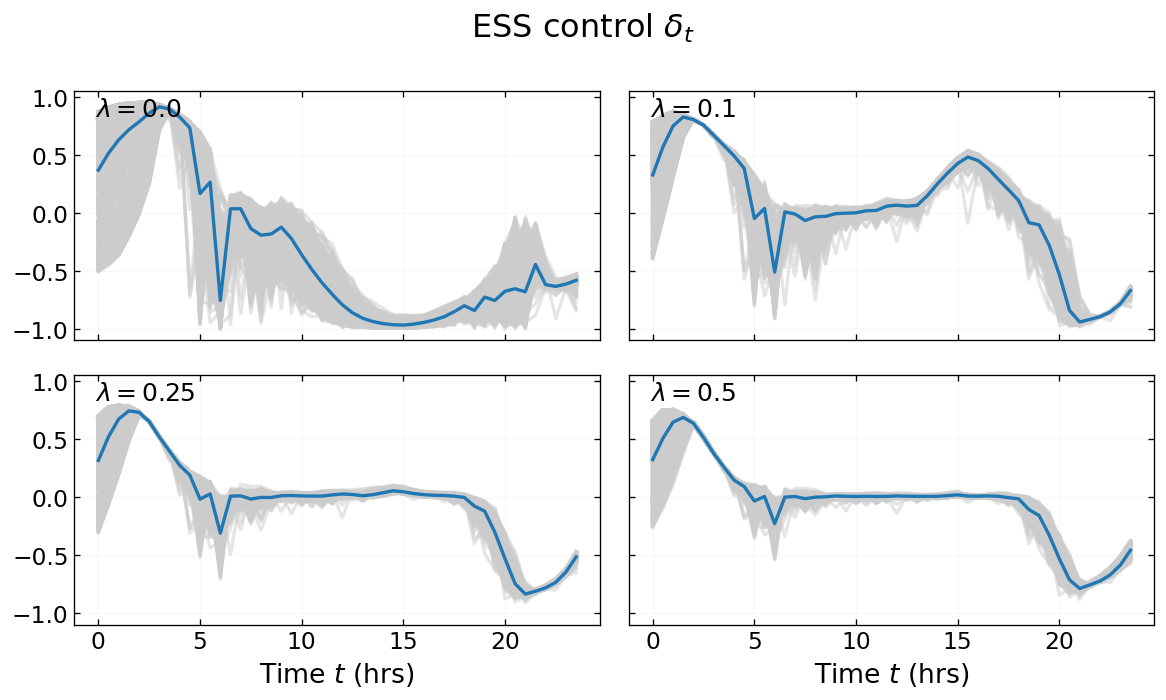

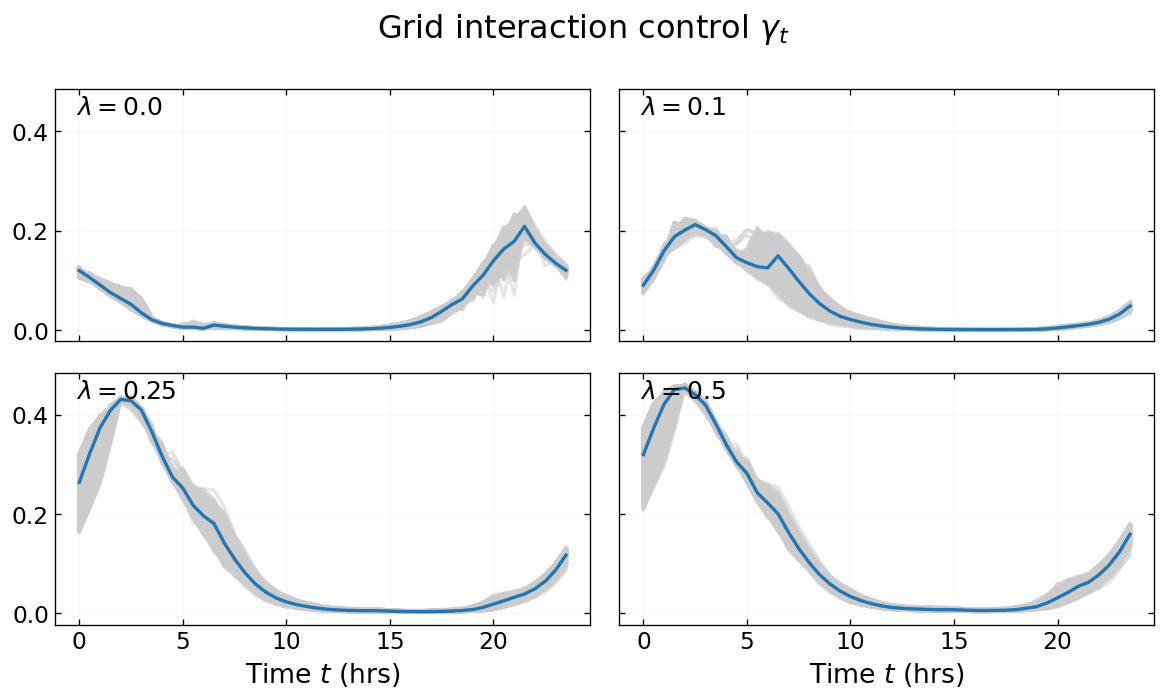

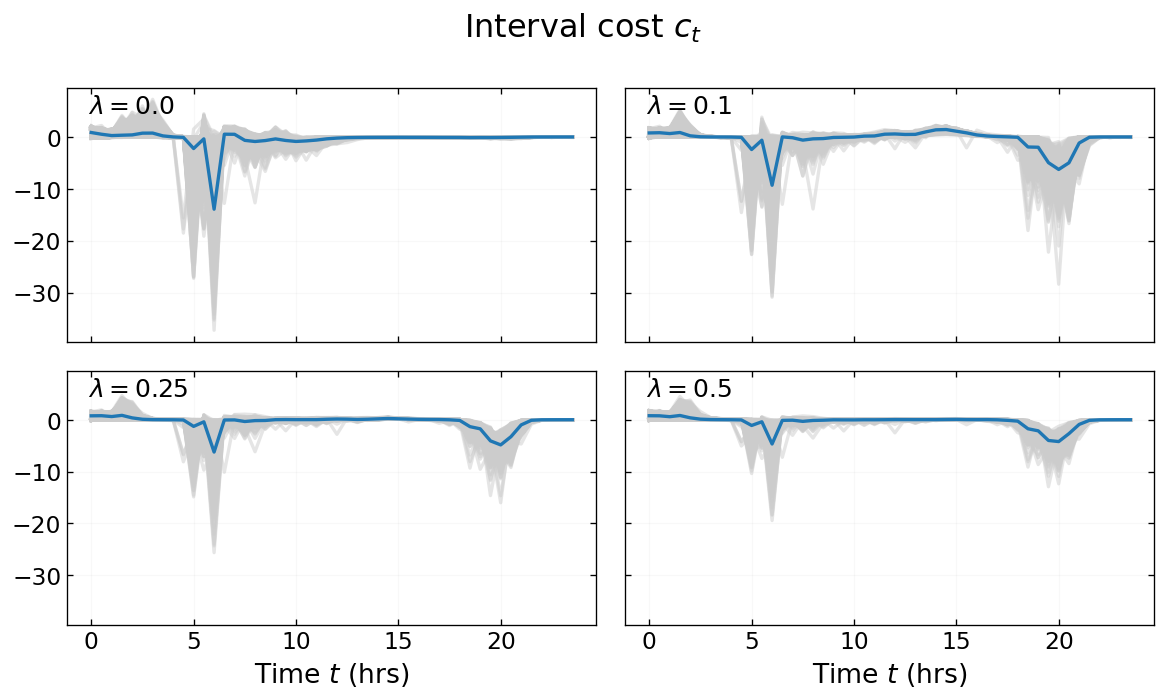

In [10]:
plot_variable_across_lambdas(
    traj_results, "E", r"Stored energy $E_t$ (kWh)", "../figures/lambda_E_many.pdf"
)
plot_variable_across_lambdas(
    traj_results, "eta", r"Charging control $\eta_t$", "../figures/lambda_eta_many.pdf"
)
plot_variable_across_lambdas(
    traj_results, "delta", r"ESS control $\delta_t$", "../figures/lambda_delta_many.pdf"
)
plot_variable_across_lambdas(
    traj_results, "gamma", r"Grid interaction control $\gamma_t$", "../figures/lambda_gamma_many.pdf"
)
plot_variable_across_lambdas(
    traj_results, "c", r"Interval cost $c_t$", "../figures/lambda_cost_many.pdf"
)

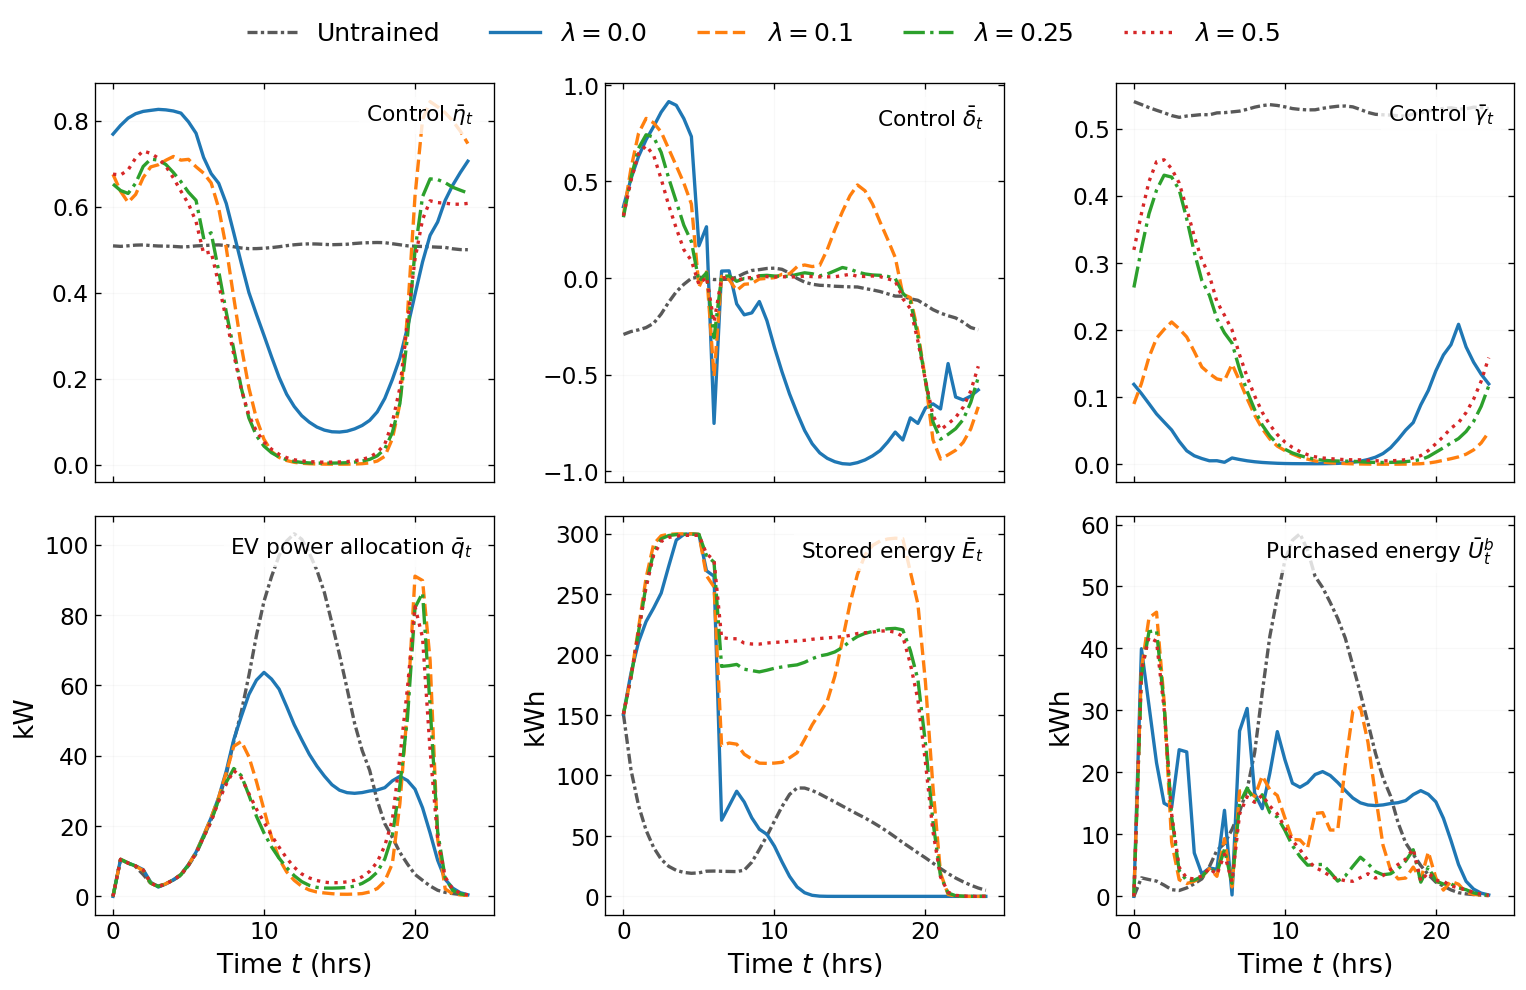

In [11]:
plot_mean_trajectory_summary(
    traj_results, untrained_res,
    save_path="../figures/lambda_mean_trajectory_summary.pdf"
    )

In [12]:
lambda_ = 0.0

policy = NeuralPolicy()
state_dict = checkpoint[lambda_]["best_state"]   # o "best_state"
policy.load_state_dict(state_dict)
policy.eval()

NeuralPolicy(
  (out_acts): ModuleList(
    (0): Sigmoid()
    (1): Tanh()
    (2): Sigmoid()
  )
  (backbone): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
  )
  (head): Linear(in_features=16, out_features=3, bias=True)
)

In [ ]:
history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    stochastic=True,
    seed=123,
    device=device
)

In [ ]:
plot_state_trajectories(history["time"], history["state"])
plot_control_trajectories(history["time"], history["control"])
plot_endogenous_trajectories(history["time"], history["endog"])
plot_cost_trajectories(history["time"], history["cost"], history["J_episode"])

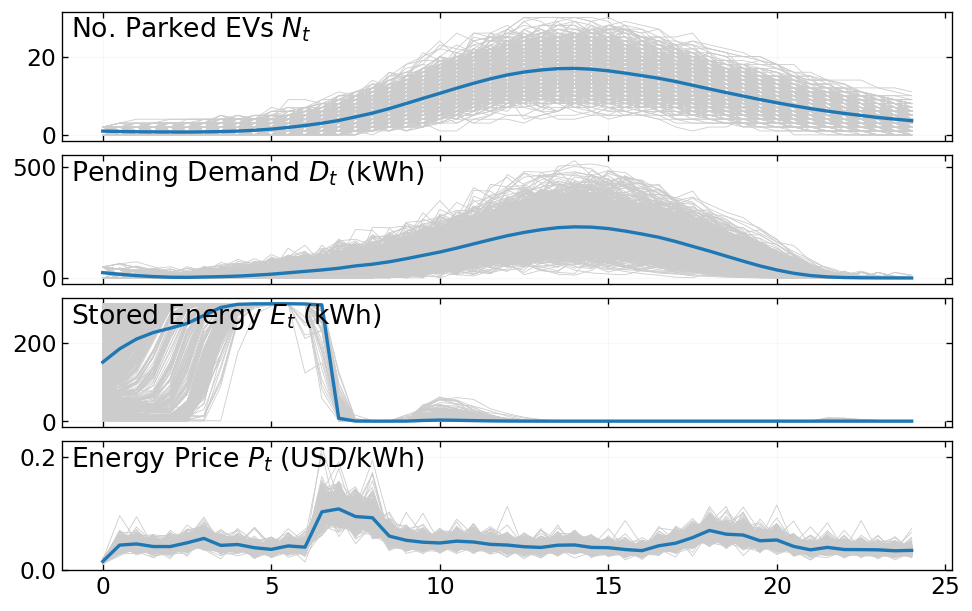

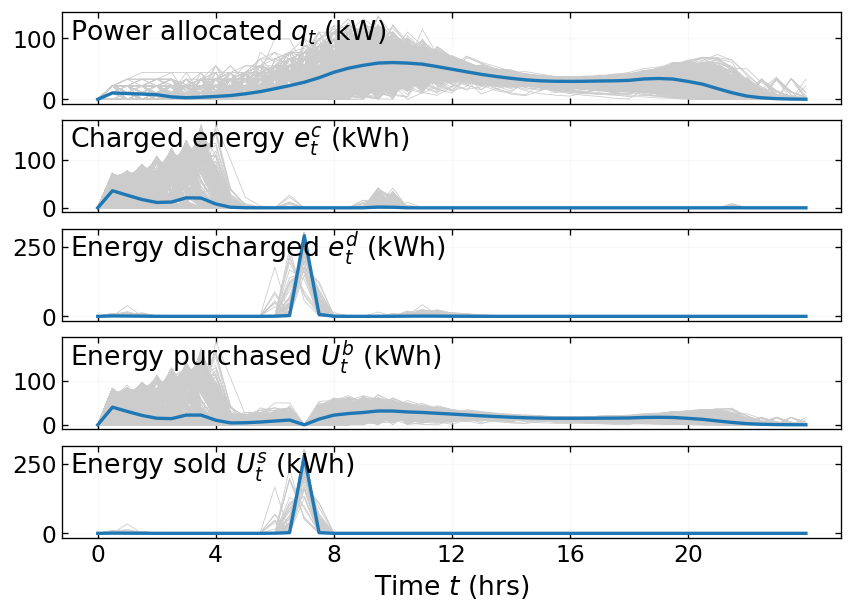

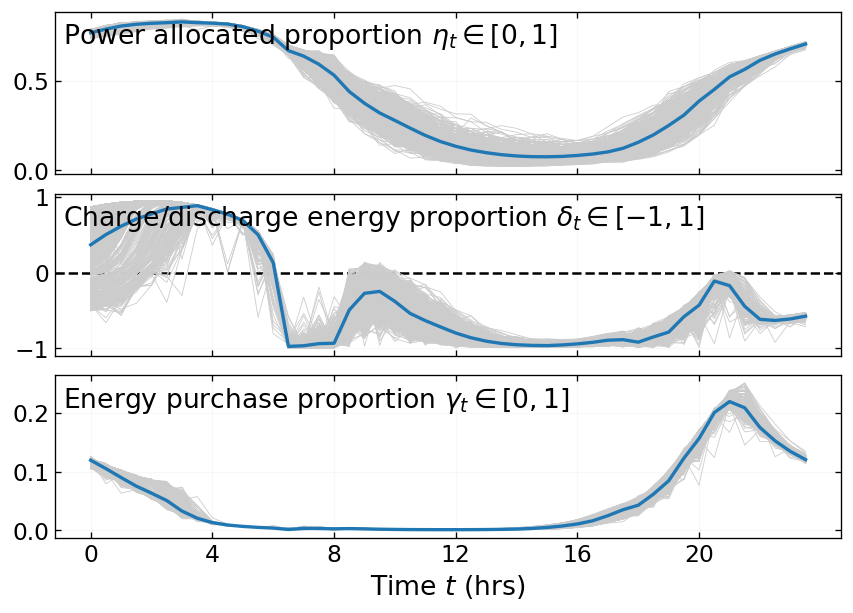

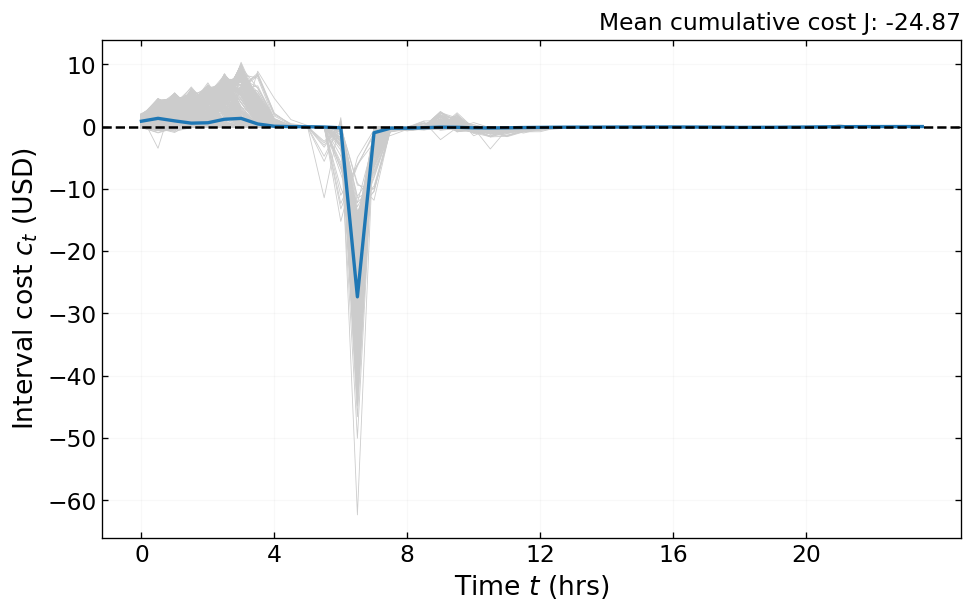

In [ ]:
lambda_str = str(lambda_).replace(".", "_")

plot_state_trajectories(
    history["time"], history["state"], f"../figures/states_trained_nn_lambda_{lambda_str}.pdf"
)
plot_endogenous_trajectories(
    history["time"], history["endog"], f'../figures/endog_trained_nn_lambda_{lambda_str}.pdf'
)
plot_control_trajectories(
    history["time"], history["control"], f"../figures/controls_trained_nn_lambda_{lambda_str}.pdf"
)
plot_cost_trajectories(
    history["time"], history["cost"], history["J_episode"],
    f"../figures/costs_trained_nn_lambda_{lambda_str}.pdf"
)